In [7]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("./customers_export.csv")

# --- DATA CLEANING ---

# 1. Drop columns that are irrelevant for business/SEO analysis
# PasswordHash, PasswordSalt, and rowguid are technical identifiers not useful for customer insights
# NameStyle has only 1 unique value ('False'), providing no information
cols_to_drop = ['PasswordHash', 'PasswordSalt', 'rowguid', 'NameStyle']
df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')

# 2. Handle missing values
# Suffix is mostly empty (799/847), so we drop it
# Title and MiddleName can be filled with 'Unknown'
df_cleaned = df_cleaned.drop(columns=['Suffix'], errors='ignore')
df_cleaned['Title'] = df_cleaned['Title'].fillna('Unknown')
df_cleaned['MiddleName'] = df_cleaned['MiddleName'].fillna('Unknown')

# 3. Standardize data types
# Convert ModifiedDate to datetime objects
df_cleaned['ModifiedDate'] = pd.to_datetime(df_cleaned['ModifiedDate'])

# 4. Standardize Phone numbers (removing non-numeric characters for cleaner analysis)
df_cleaned['Phone'] = df_cleaned['Phone'].astype(str).str.replace(r'\D', '', regex=True)

# 5. Extract domain from EmailAddress for SEO/Marketing persona analysis
df_cleaned['EmailDomain'] = df_cleaned['EmailAddress'].apply(lambda x: x.split('@')[-1])

# Save cleaned data
cleaned_file_path = './cleaned_customers.csv'
df_cleaned.to_csv(cleaned_file_path, index=False)

# --- EDA PREPARATION ---
# Displaying info and head to verify cleaning
print(df_cleaned.info())
print(df_cleaned.head())

<class 'pandas.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   CustomerID    847 non-null    int64         
 1   Title         847 non-null    str           
 2   FirstName     847 non-null    str           
 3   MiddleName    847 non-null    str           
 4   LastName      847 non-null    str           
 5   CompanyName   847 non-null    str           
 6   SalesPerson   847 non-null    str           
 7   EmailAddress  847 non-null    str           
 8   Phone         847 non-null    str           
 9   ModifiedDate  847 non-null    datetime64[us]
 10  EmailDomain   847 non-null    str           
dtypes: datetime64[us](1), int64(1), str(9)
memory usage: 72.9 KB
None
   CustomerID Title FirstName MiddleName    LastName  \
0           1   Mr.   Orlando         N.         Gee   
1           2   Mr.     Keith    Unknown      Harris   
2           3   M

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")


In [2]:
# Load cleaned dataset
df = pd.read_csv('cleaned_customers.csv', parse_dates=['ModifiedDate'])

# Quick preview
df.head()


,CustomerID,Title,FirstName,MiddleName,LastName,CompanyName,SalesPerson,EmailAddress,Phone,ModifiedDate,EmailDomain
0,1,Mr.,Orlando,N.,Gee,A Bike Store,adventure-works\pamela0,orlando0@adventure-works.com,2455550173,2005-08-01,adventure-works.com
1,2,Mr.,Keith,Unknown,Harris,Progressive Sports,adventure-works\david8,keith0@adventure-works.com,1705550127,2006-08-01,adventure-works.com
2,3,Ms.,Donna,F.,Carreras,Advanced Bike Components,adventure-works\jillian0,donna0@adventure-works.com,2795550130,2005-09-01,adventure-works.com
3,4,Ms.,Janet,M.,Gates,Modular Cycle Systems,adventure-works\jillian0,janet1@adventure-works.com,7105550173,2006-07-01,adventure-works.com
4,5,Mr.,Lucy,Unknown,Harrington,Metropolitan Sports Supply,adventure-works\shu0,lucy0@adventure-works.com,8285550186,2006-09-01,adventure-works.com


In [3]:
# Check shape
print("Dataset shape:", df.shape)

# Check data types and missing values
print(df.info())

# Summary statistics for object and numeric columns
display(df.describe(include='all'))


Dataset shape: (847, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   CustomerID    847 non-null    int64         
 1   Title         847 non-null    object        
 2   FirstName     847 non-null    object        
 3   MiddleName    847 non-null    object        
 4   LastName      847 non-null    object        
 5   CompanyName   847 non-null    object        
 6   SalesPerson   847 non-null    object        
 7   EmailAddress  847 non-null    object        
 8   Phone         847 non-null    int64         
 9   ModifiedDate  847 non-null    datetime64[ns]
 10  EmailDomain   847 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 72.9+ KB
None


,CustomerID,Title,FirstName,MiddleName,LastName,CompanyName,SalesPerson,EmailAddress,Phone,ModifiedDate,EmailDomain
count,847.000000,847,847,847,847,847,847,847,8.470000e+02,847,847
unique,NaN,5,315,29,398,439,9,440,NaN,NaN,1
top,NaN,Mr.,Robert,Unknown,Miller,Friendly Bike Shop,adventure-works\shu0,linda5@adventure-works.com,NaN,NaN,adventure-works.com
freq,NaN,490,22,343,10,4,151,2,NaN,NaN,847
mean,14503.217237,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.072676e+11,2006-07-16 04:35:14.912571392,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.035550e+09,2005-07-01 00:00:00,NaN
25%,330.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.655550e+09,2005-09-01 00:00:00,NaN
50%,672.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.515550e+09,2006-08-01 00:00:00,NaN
75%,29798.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.095550e+09,2007-06-01 00:00:00,NaN
max,30118.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.115006e+12,2009-05-16 16:33:33.123000,NaN


In [4]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [5]:
# Missing values per column
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'MissingCount': missing_values,
    'MissingPercent': missing_percent
})

display(missing_df)


,MissingCount,MissingPercent
CustomerID,0,0.0
Title,0,0.0
FirstName,0,0.0
MiddleName,0,0.0
LastName,0,0.0
CompanyName,0,0.0
SalesPerson,0,0.0
EmailAddress,0,0.0
Phone,0,0.0
ModifiedDate,0,0.0


Title
Mr.        490
Ms.        340
Unknown      7
Sr.          6
Sra.         4
Name: count, dtype: int64


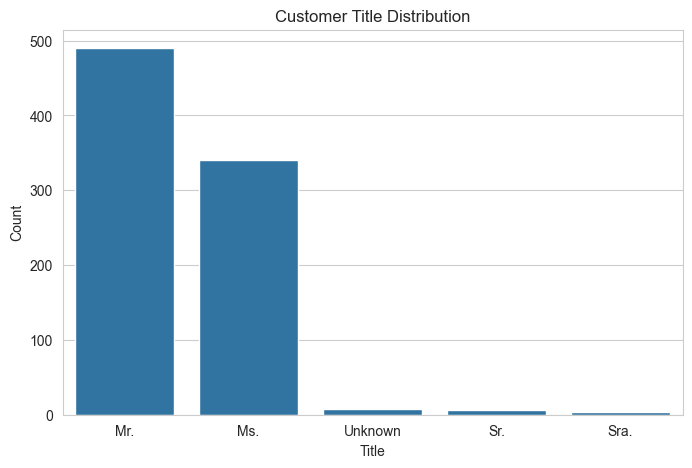

In [6]:
# Count customers by title
title_counts = df['Title'].value_counts()

print(title_counts)

# Plot title distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Title', order=df['Title'].value_counts().index)
plt.title('Customer Title Distribution')
plt.xlabel('Title')
plt.ylabel('Count')
plt.show()


CompanyName
Friendly Bike Shop          4
Countryside Company         2
Aerobic Exercise Company    2
Rural Cycle Emporium        2
Future Bikes                2
A Bike Store                2
Progressive Sports          2
Solid Bike Parts            2
Small Bike Shop             2
Sports Products Store       2
Name: count, dtype: int64


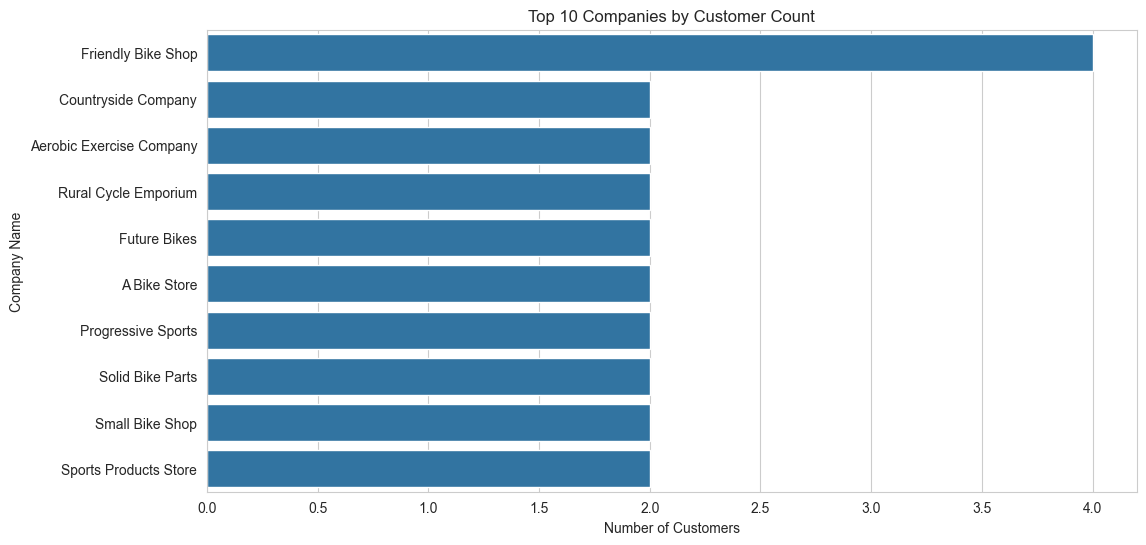

In [8]:
# Top 10 companies by customer count
top_companies = df['CompanyName'].value_counts().head(10)

print(top_companies)

# Plot top companies
plt.figure(figsize=(12,6))
sns.barplot(x=top_companies.values, y=top_companies.index)
plt.title('Top 10 Companies by Customer Count')
plt.xlabel('Number of Customers')
plt.ylabel('Company Name')
plt.show()


SalesPerson
adventure-works\shu0        151
adventure-works\jillian0    148
adventure-works\josé1       142
adventure-works\jae0         78
adventure-works\garrett1     78
adventure-works\pamela0      74
adventure-works\david8       73
adventure-works\linda3       71
adventure-works\michael9     32
Name: count, dtype: int64


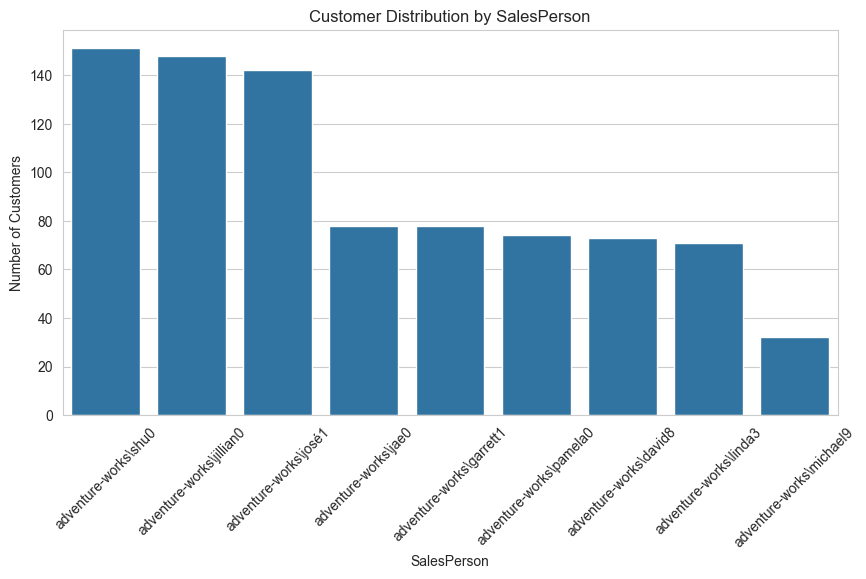

In [9]:
# Count customers per salesperson
salesperson_counts = df['SalesPerson'].value_counts()

print(salesperson_counts)

# Plot salesperson distribution
plt.figure(figsize=(10,5))
sns.barplot(x=salesperson_counts.index, y=salesperson_counts.values)
plt.title('Customer Distribution by SalesPerson')
plt.xlabel('SalesPerson')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()


EmailDomain
adventure-works.com    847
Name: count, dtype: int64


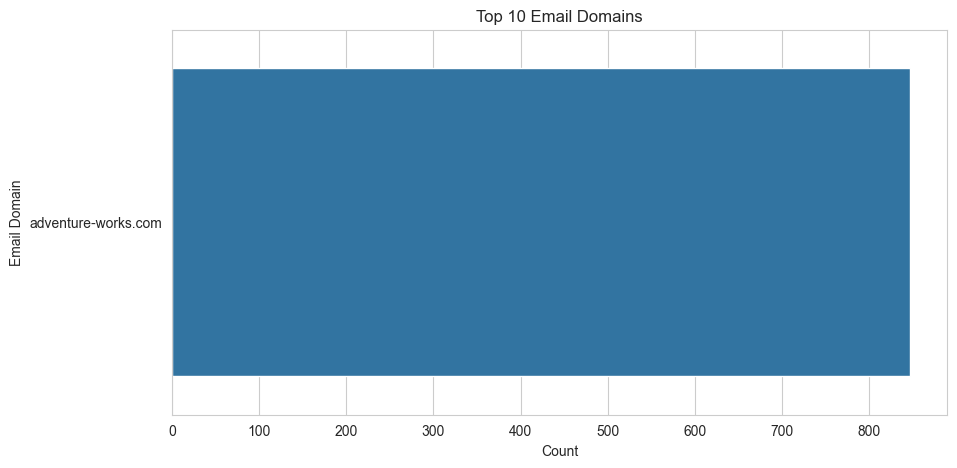

In [10]:
# Top email domains
top_domains = df['EmailDomain'].value_counts().head(10)

print(top_domains)

# Plot top email domains
plt.figure(figsize=(10,5))
sns.barplot(x=top_domains.values, y=top_domains.index)
plt.title('Top 10 Email Domains')
plt.xlabel('Count')
plt.ylabel('Email Domain')
plt.show()


YearMonth
2005-07     52
2005-08    120
2005-09     91
2005-10      4
2005-11     28
2005-12     13
2006-01      4
2006-03      2
2006-06      2
2006-07     58
2006-08    105
2006-09    116
2006-10      6
2006-11      8
2006-12     12
2007-02      6
2007-03      2
2007-04      2
2007-05      3
2007-06      2
2007-07     38
2007-08     63
2007-09     94
2008-02      2
2008-06      4
2009-05     10
Name: count, dtype: int64


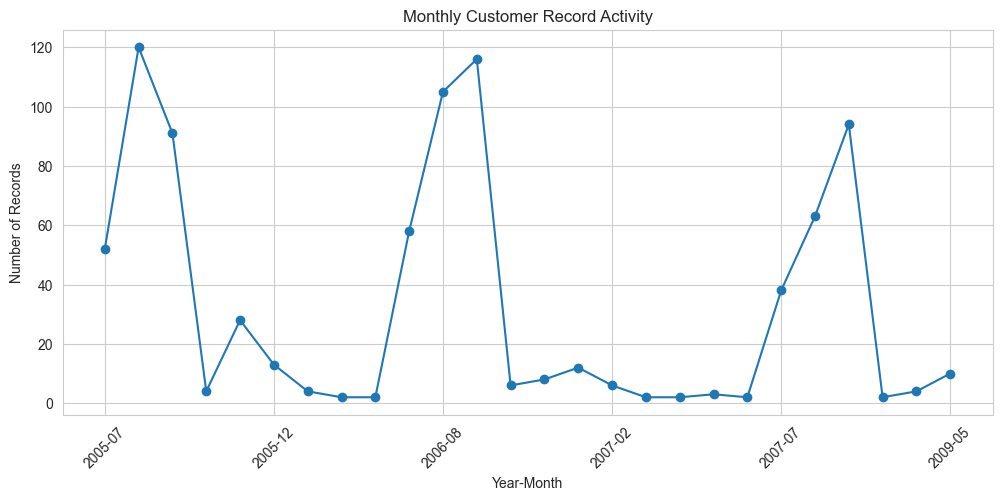

In [11]:
# Create year-month column
df['YearMonth'] = df['ModifiedDate'].dt.to_period('M').astype(str)

# Count records by month
monthly_activity = df['YearMonth'].value_counts().sort_index()

print(monthly_activity)

# Plot monthly trend
plt.figure(figsize=(12,5))
monthly_activity.plot(kind='line', marker='o')
plt.title('Monthly Customer Record Activity')
plt.xlabel('Year-Month')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()


Year
2005    308
2006    313
2007    210
2008      6
2009     10
Name: count, dtype: int64


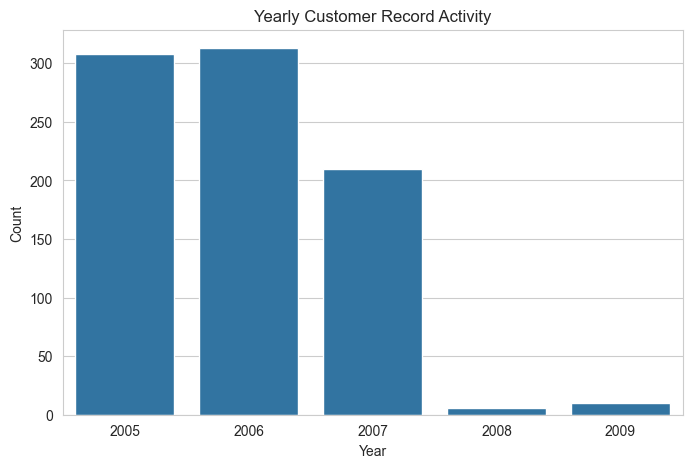

In [13]:
# Extract year
df['Year'] = df['ModifiedDate'].dt.year

yearly_activity = df['Year'].value_counts().sort_index()

print(yearly_activity)

# Plot yearly activity
plt.figure(figsize=(8,5))
sns.barplot(x=yearly_activity.index, y=yearly_activity.values)
plt.title('Yearly Customer Record Activity')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


PhoneLength
10    769
13     78
Name: count, dtype: int64


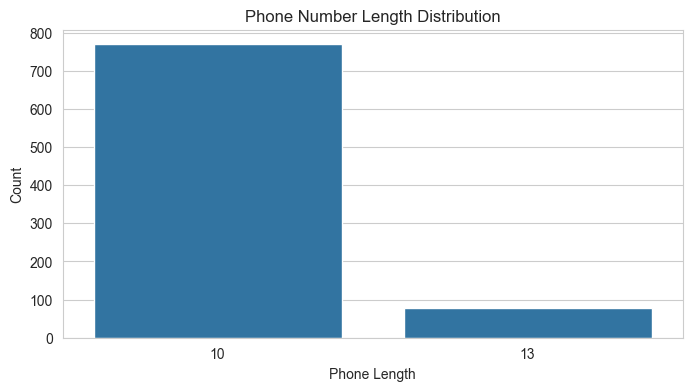

In [14]:
# Check phone number lengths
df['PhoneLength'] = df['Phone'].astype(str).str.len()

phone_length_counts = df['PhoneLength'].value_counts().sort_index()
print(phone_length_counts)

# Plot phone length distribution
plt.figure(figsize=(8,4))
sns.barplot(x=phone_length_counts.index, y=phone_length_counts.values)
plt.title('Phone Number Length Distribution')
plt.xlabel('Phone Length')
plt.ylabel('Count')
plt.show()


In [15]:
# Create full name column
df['FullName'] = (
    df['FirstName'].fillna('') + ' ' +
    df['MiddleName'].fillna('') + ' ' +
    df['LastName'].fillna('')
).str.replace(r'\s+', ' ', regex=True).str.strip()

df[['CustomerID', 'FullName']].head()


,CustomerID,FullName
0,1,Orlando N. Gee
1,2,Keith Unknown Harris
2,3,Donna F. Carreras
3,4,Janet M. Gates
4,5,Lucy Unknown Harrington


In [16]:
# Save analysis-ready dataset
df.to_csv('customers_analysis_ready.csv', index=False)

print("File saved successfully.")


File saved successfully.
